# Python data therapy

Sometimes, when your code doesn't work the way you think it should, it's because of the way you're representing data. This workshop covers three modern Python libraries for representing data:

1. Use `Pydantic` to enforce a data contract
1. Use `Polars` to analyze a data set that fits in memory
1. Use `DuckDB` to analyze a data set too large for memory

## Pydantic

One way that your data representation can cause problems is if you aren't able to guarantee that it has the correct information. 

For example, let's say you have a tuple of values that represent the population, total area, and water area for a tract. And a function that computes the population density per unit land area.

In [587]:
tract = (3000, 4.0, 1.0)

def pop_density(tract):
    land_area = tract[1] - tract[2]
    return tract[0] / land_area


pop_density(tract)

1000.0

There are lots of ways for this to go wrong. What if the attributes are in a different order?

In [559]:
tract = (3000, 1.0, 4.0)
pop_density(tract)

-1000.0

Or an attribute is missing?

In [588]:
tract = (3000, 4.0)
pop_density(tract)

IndexError: tuple index out of range

Or the attributes are an unexpected data type?

In [589]:
tract = ("3000", "4.0", "1.0")
pop_density(tract)

TypeError: unsupported operand type(s) for -: 'str' and 'str'

### Parsing data

These types of problems are especially common at the boundaries of your code, when you are interacting with data that came from somewhere else. What you want is a way to be sure up front that any data you're working with has the information you expect it to have.

Pydantic is a library for parsing data. Parsing means getting data into a form that you know is correct.

This requires you to know the correct form, which is not trivial. It may not always be possible. Or maybe not possible with a reasonable amount of effort. It's a constraint that you balance against other constraints. But getting your data into a form you know is correct should have a relatively high priority. 

Pydantic can create what's called a model with all the fields the data should have, and the acceptable data type for each field. Most models work by inheriting from the `BaseModel` class.

In [590]:
from pydantic import BaseModel


class Tract(BaseModel):
    population: int
    total_area: float
    water_area: float

You can rewrite the `pop_density` function to take an instance of the `Tract` model instead of a tuple. Because you can access the values by name, instead of by index number, the function is also much more clear.  

Notice also that instances of the `Tract` model are constructed differently from the raw tuples used above.

In [591]:
def pop_density(tract):
    land_area = tract.total_area - tract.water_area
    return tract.population / land_area

tract = Tract(population=3000, total_area=4.0, water_area=1.0)
pop_density(tract)

1000.0

It doesn't matter if the attributes are in a different order, because they are named

In [592]:
tract = Tract(population=3000, water_area=1.0, total_area=4.0)
pop_density(tract)

1000.0

If you don't have the right information, Pydantic has helpful error messages that tell you about the problem before you try to use the data. That's good because if something is going to fail, you want it to fail fast.

In [593]:
tract = Tract(population=3000, total_area=4.0)

ValidationError: 1 validation error for Tract
water_area
  Field required [type=missing, input_value={'population': 3000, 'total_area': 4.0}, input_type=dict]
    For further information visit https://errors.pydantic.dev/2.12/v/missing

Models can have default values, so the model is still created even if you don't pass the value explicitly

In [594]:
class Tract(BaseModel):
    population: int
    total_area: float
    water_area: float = 0.0

tract = Tract(population=3000, total_area=4.0)
print(tract)

population=3000 total_area=4.0 water_area=0.0


Pydantic can also coerce some datatypes into the expected types, such as a `str` into `int` or `float`.

In [595]:
tract = Tract(population="3000", total_area="4.0", water_area="1.0")
print(tract)
pop_density(tract)


population=3000 total_area=4.0 water_area=1.0


1000.0

But if it can't coerce values, it will tell you the value is the wrong type.

In [596]:
tract = Tract(population=3000, total_area=4.0, water_area=None)

ValidationError: 1 validation error for Tract
water_area
  Input should be a valid number [type=float_type, input_value=None, input_type=NoneType]
    For further information visit https://errors.pydantic.dev/2.12/v/float_type

### Advanced validation

Pydantic can do more than just ensure the right values with the right data types are present. It can also make sure the values are in the right range with the `Field` class. For example, to ensure that the `population` and `water_area` are not negative, and that the `total_area` is greater than zero.

If any of the values are wrong, Pydantic will let you know about all of the wrong values, not just fail on the first wrong one.

In [ ]:
from pydantic import Field


class Tract(BaseModel):
    population: int = Field(ge=0)
    total_area: float = Field(gt=0)
    water_area: float = Field(default=0, ge=0)

tract = Tract(population=-1, total_area=0)


ValidationError: 2 validation errors for Tract
population
  Input should be greater than or equal to 0 [type=greater_than_equal, input_value=-1, input_type=int]
    For further information visit https://errors.pydantic.dev/2.12/v/greater_than_equal
total_area
  Input should be greater than 0 [type=greater_than, input_value=0, input_type=int]
    For further information visit https://errors.pydantic.dev/2.12/v/greater_than

You can also do more advanced validation with Pydantic using the `model_validator`. For example, ensuring that `water_area` is not larger than `total_area`.

In [603]:
from pydantic import model_validator


class Tract(BaseModel):
    population: int = Field(ge=0)
    total_area: float = Field(gt=0)
    water_area: float = Field(default=0.0, ge=0)

    @model_validator(mode="after")
    def check_water_area(self):
        if self.water_area > self.total_area:
            raise ValueError("Water area cannot be larger than total area")
        return self
    
tract = Tract(population=3000, total_area=1.0, water_area=4.0)



ValidationError: 1 validation error for Tract
  Value error, Water area cannot be larger than total area [type=value_error, input_value={'population': 3000, 'tot... 1.0, 'water_area': 4.0}, input_type=dict]
    For further information visit https://errors.pydantic.dev/2.12/v/value_error

### Instantiating models from inputs

If your model fields correspond to the keys of a dictionary, you can use `model_validate` to create an instance of the model from that dictionary directly.

In [604]:
tract_data = {"population": 3000, "total_area": 4.0}
tract = Tract.model_validate(tract_data)
print(tract)

population=3000 total_area=4.0 water_area=0.0


The `model_validate_json` method does the same thing for json strings, such as those you might get from a REST endpoint.

In [605]:
tract_json = '{"population": "3000", "total_area": "4.0"}'
tract = Tract.model_validate_json(tract_json)
print(tract)

population=3000 total_area=4.0 water_area=0.0


You can create nested models, where the type of a field in one model references some other model. This allows you to parse nested data.

In [606]:
class County(BaseModel):
    name: str
    tracts: list[Tract]

county_json = """{
    "name": "Example County",
    "tracts": [
        {"population": "1000", "total_area": "5"},
        {"population": "3000", "total_area": "7", "water_area": "2"}
    ]
}"""

County.model_validate_json(county_json)

County(name='Example County', tracts=[Tract(population=1000, total_area=5.0, water_area=0.0), Tract(population=3000, total_area=7.0, water_area=2.0)])

Because lots of other tools have been built on top of Pydantic, you can get many of its advantages without having to write the models yourself. One particularly useful tool is `geojson_pydantic`, which validates that data adheres to the GeoJSON standard.

In [574]:
from geojson_pydantic import Point

geojson = """{
    "type": "Point",
    "coordinates": [-95, 45]
}"""

point = Point.model_validate_json(geojson)
print(point)

bbox=None type='Point' coordinates=Position2D(longitude=-95.0, latitude=45.0)


### Exercise: Create Pydantic models from CSV

- Option 1: On the Python data problems page, do problems 1 and 2. These problems give you all the lines of code, and you drag and drop them into the right order until the code runs successfully. Then answer these questions:

    1. Why did the `State` model need to be defined after the `County` model?
    1. In problem 1, why was it OK to create an instance of the `State` model without actually giving it information for the `counties` field?
    1. In problem 1, what would the value of the `state` variable be if the data on row 30 didn't match the requirements of the `County` model? (hint: copy the code and run it locally after you change the value on row 30 of `data/mn_counties.csv` to see what happens)
    1. What if that same issue happened in problem 2?
- Option 2: Write a script from scratch that creates a Pydantic model that matches the schema in `data/mn_counties.csv` and then creates instances of the model for each row in that file.


## Polars

Another way your data representation can cause problems is that some ways of representing data make your code slow. The two biggest sources of unnecessary slowdown are data representations that require:

- Using Python loops for processing
- Looking at all the data when the question only requires a subset of it

You may already know about a library called Pandas that represents tabular data in a way that can solve the first problem. Polars is similar to Pandas, but better in that it can solve both of these problems.

### Dataframes

You can read a variety of file types into a Polars dataframe. It is especially good for reading Parquet files because Polars represents data in memory using the Apache Arrow specification, which is the same way Parquet files were designed to be read. This means the data usually don't have to be transformed after reading them into memory from the file, making file I/O faster.

In [620]:
import polars as pl

df = pl.read_parquet("data/mn_counties.parquet")
display(df)

name,fips,region,population,area_km2
str,i64,str,i64,i64
"""Aitkin""",1,"""Northland""",16252,4711
"""Anoka""",3,"""Twin Cities""",381605,1097
"""Becker""",5,"""West Central""",35497,3394
"""Beltrami""",7,"""Northwest""",47055,6489
"""Benton""",9,"""Central""",41744,1057
…,…,…,…,…
"""Watonwan""",165,"""Southern""",11459,1125
"""Wilkin""",167,"""West Central""",6288,1947
"""Winona""",169,"""Southern""",50523,1622


Like Pandas, in Polars you can use bracket notation to get a column of data, called a series.

In [619]:
df["name"]

name
str
"""Benton"""
"""Cass"""
"""Chisago"""
"""Crow Wing"""
"""Isanti"""
…
"""Sherburne"""
"""Stearns"""
"""Todd"""


But unlike Pandas, this is usually a bad idea in Polars. It's better use the `col` function to specify a column by name. This is the most common way to create what's called an expression, which are the fundamental unit of work in Polars. 

In [621]:
population_col = pl.col("population")
print(population_col)

col("population")


Importantly, expressions don't actually do anything by themselves. They are like recipes, not cooking. To do any work, expressions need a context. For example, use the `select` context when you want just the results of the expressions you specify.

In [622]:
df.select(population_col)

population
i64
16252
381605
35497
47055
41744
…
11459
6288
50523


The same expression produces different results in different contexts. For example, use the `with_columns` context when you want all the columns of the original table and also the results of the expressions you specify

In the example below, the `population` column already exists, so it is overwritten with the values in the `population_col` expression.

In [623]:
df.with_columns(population_col)

name,fips,region,population,area_km2
str,i64,str,i64,i64
"""Aitkin""",1,"""Northland""",16252,4711
"""Anoka""",3,"""Twin Cities""",381605,1097
"""Becker""",5,"""West Central""",35497,3394
"""Beltrami""",7,"""Northwest""",47055,6489
"""Benton""",9,"""Central""",41744,1057
…,…,…,…,…
"""Watonwan""",165,"""Southern""",11459,1125
"""Wilkin""",167,"""West Central""",6288,1947
"""Winona""",169,"""Southern""",50523,1622


### Lazyframes

On its face, using an expression inside a context seems more complicated and therefore worse than simple bracket notation. But the idea that expressions are plans (not work) is vital for using Polars effectively. 

So far, these examples have created a dataframe. In Polars, dataframes are eager. Data are immediately read into memory when you create a dataframe. The methods you call on a dataframe are executed immediately. Polars dataframes largely correspond to how Pandas dataframes work.

But one of the big advantages of Polars is the lazyframe. Lazyframes, like expressions, aren't work. They are a plan for doing work. Data aren't immediately read into memory when you create a lazyframe. The methods you call on them aren't immediately executed. Instead, the work is done only when you materialize the lazyframe (called collection in Polars). That's usually better because Polars can optimize all those operations.

As an analogy, imagine you're grocery shopping. A dataframe is like thinking about what you need one item at a time, and grabbing each item as you think about it, no matter where it is in the store. A lazyframe is like making a grocery list. Collecting the lazyframe is like organizing your list by item location, then doing the shopping based on that organized list.

You can convert a dataframe to a lazyframe with the `lazy` method and collect a lazyframe with the `collect` method.

In [624]:
lf = df.lazy()
lf.collect()

name,fips,region,population,area_km2
str,i64,str,i64,i64
"""Aitkin""",1,"""Northland""",16252,4711
"""Anoka""",3,"""Twin Cities""",381605,1097
"""Becker""",5,"""West Central""",35497,3394
"""Beltrami""",7,"""Northwest""",47055,6489
"""Benton""",9,"""Central""",41744,1057
…,…,…,…,…
"""Watonwan""",165,"""Southern""",11459,1125
"""Wilkin""",167,"""West Central""",6288,1947
"""Winona""",169,"""Southern""",50523,1622


You can also create a lazyframe when you first read data by using one of the `scan_*` functions instead of the `read_*` functions. If you don't collect the lazyframe, you just get a query plan (the grocery list) not the data (the groceries).

In [625]:
lf = pl.scan_parquet("data/mn_counties.parquet")
display(lf)

Lazyframes also work well with reading multiple files at once by using glob patterns or pointing at a directory, such as hive partitioned Parquet files.

In [627]:
lf = pl.scan_parquet("data/mn_counties/region=South*/*", hive_partitioning=True)
lf.collect()

name,fips,population,area_km2,region
str,i64,i64,i64,str
"""Blue Earth""",13,70634,1949,"""Southern"""
"""Brown""",15,25517,1582,"""Southern"""
"""Dodge""",39,21376,1138,"""Southern"""
"""Faribault""",43,13888,1848,"""Southern"""
"""Fillmore""",45,21540,2231,"""Southern"""
…,…,…,…,…
"""Redwood""",127,15265,2278,"""Southwest"""
"""Renville""",129,14356,2546,"""Southwest"""
"""Rock""",133,9524,1250,"""Southwest"""


In [628]:
lf = pl.scan_parquet("data/mn_counties", hive_partitioning=True)
lf.collect()

name,fips,population,area_km2,region
str,i64,i64,i64,str
"""Benton""",9,41744,1057,"""Central"""
"""Cass""",21,31430,5226,"""Central"""
"""Chisago""",25,59142,1082,"""Central"""
"""Crow Wing""",35,69132,2581,"""Central"""
"""Isanti""",59,44386,1137,"""Central"""
…,…,…,…,…
"""Otter Tail""",111,61041,5127,"""West Central"""
"""Pope""",121,11420,1736,"""West Central"""
"""Stevens""",149,9747,1456,"""West Central"""


### Vectorization

You can use Polars expressions to batch operations over an entire group of values. That's good, because otherwise you would need to write a slow Python loop to process each value one at a time. This batching is called "vectorization", and can make code execution 100x faster (or more).

For example, if you wanted to find the counties with population over 100,000 people, you wouldn't loop over every row in the table and check whether its population met the threshold. You would use a logical operator to compare the entire `population` column to the threshold.

Vectorized logical operations like this are very useful in the `filter` context, which filters the rows based on expressions that return a boolean value.

In [629]:
large_counties = pl.col("population") > 100000
lf.filter(large_counties).collect()

name,fips,population,area_km2,region
str,i64,i64,i64,str
"""Sherburne""",141,104194,1130,"""Central"""
"""Stearns""",145,164110,3482,"""Central"""
"""Wright""",171,157559,1711,"""Central"""
"""Saint Louis""",137,200518,16123,"""Northland"""
"""Olmsted""",109,166731,1691,"""Southern"""
…,…,…,…,…
"""Dakota""",37,457710,1475,"""Twin Cities"""
"""Hennepin""",53,1284784,1442,"""Twin Cities"""
"""Ramsey""",123,541623,403,"""Twin Cities"""


In addition to logical operators, you can use entire columns in vectorized arithmetic operations. For example, if you want a column of population density, you can divide the `population` column by the `area_km2` column.  

In [630]:
pop_density = pl.col("population") / pl.col("area_km2")
lf.with_columns(pop_density).collect()

name,fips,population,area_km2,region
str,i64,f64,i64,str
"""Benton""",9,39.492904,1057,"""Central"""
"""Cass""",21,6.01416,5226,"""Central"""
"""Chisago""",25,54.659889,1082,"""Central"""
"""Crow Wing""",35,26.784967,2581,"""Central"""
"""Isanti""",59,39.037819,1137,"""Central"""
…,…,…,…,…
"""Otter Tail""",111,11.905793,5127,"""West Central"""
"""Pope""",121,6.578341,1736,"""West Central"""
"""Stevens""",149,6.694368,1456,"""West Central"""


Notice that this expression put the population density values into the `population` column. That's bad both because it overwrote data you might still want and also because the data have been transformed in such a way that `population` is not a good name for those values.

This happened because an expression's default name is based on the "left hand rule" - it keeps the name of the first column in the expression. Because the expression's name is `population`, it replaced the original `population` column in the `with_columns` context. To prevent problems like this, it is common to change an expressions name using the `alias` method.

In [632]:
pop_density = (pl.col("population") / pl.col("area_km2")).alias("pop_density")
lf.with_columns(pop_density).collect()

name,fips,population,area_km2,region,pop_density
str,i64,i64,i64,str,f64
"""Benton""",9,41744,1057,"""Central""",39.492904
"""Cass""",21,31430,5226,"""Central""",6.01416
"""Chisago""",25,59142,1082,"""Central""",54.659889
"""Crow Wing""",35,69132,2581,"""Central""",26.784967
"""Isanti""",59,44386,1137,"""Central""",39.037819
…,…,…,…,…,…
"""Otter Tail""",111,61041,5127,"""West Central""",11.905793
"""Pope""",121,11420,1736,"""West Central""",6.578341
"""Stevens""",149,9747,1456,"""West Central""",6.694368


Other expression methods can transform the data itself using vectorized operations. Expression methods that reduce data, like `sum`, can be very useful in the last major context: `group_by`. This context always includes two parts:

- Grouping rows based on shared values for one or more expressions. Usually this is just a column name.
- Aggregating the values in each group's rows. Usually this is an expression that summarizes values to a single value.

In the example below, all the rows are grouped by region. Within each region group, the `regional_pop` expression sums the values of the `population` column. The summed value for each group is put in a new column with the same name as the expression. Because the `regional_pop` expression was constructed from the `population` column, it's name is `population`.

In [633]:
regional_pop = pl.col("population").sum()
lf.group_by(pl.col("region")).agg(regional_pop).collect()

region,population
str,i64
"""Northland""",326740
"""West Central""",241062
"""Southern""",765824
"""Northwest""",169576
"""Twin Cities""",3226013
"""Southwest""",279572
"""Central""",821618


### Structural transformations

In addition to contexts and expressions, Polars also has structural transformations. These changes the shape of the entire table.

For example, the `sort` structural transformation sorts the rows based one the values in one or more columns.

In [634]:
lf.sort(pl.col("population"), descending=True).collect()

name,fips,population,area_km2,region
str,i64,i64,i64,str
"""Hennepin""",53,1284784,1442,"""Twin Cities"""
"""Ramsey""",123,541623,403,"""Twin Cities"""
"""Dakota""",37,457710,1475,"""Twin Cities"""
"""Anoka""",3,381605,1097,"""Twin Cities"""
"""Washington""",163,286895,1014,"""Twin Cities"""
…,…,…,…,…
"""Big Stone""",11,5054,1286,"""Southwest"""
"""Kittson""",69,4031,2841,"""Northwest"""
"""Red Lake""",125,3940,1120,"""Northwest"""


Besides `sort`, another useful structural transformation is `head`, which returns just the top few rows of the table


In [635]:
lf.head(3).collect()

name,fips,population,area_km2,region
str,i64,i64,i64,str
"""Benton""",9,41744,1057,"""Central"""
"""Cass""",21,31430,5226,"""Central"""
"""Chisago""",25,59142,1082,"""Central"""


### Method chaining

In Polars, the conventional pattern is to chain expression methods, contexts, and structural transformations together. To prevent these long chains from becoming unreadable, you should:
    - Pull all but the most trivial expressions out into separate variables
    - Compose complex expressions from simpler expressions
    - Format each context and structural transformation method call onto its own line.

The example below shows a well-formatted example combining several elements to return a table with the top 3 regions in Minnesota by population density, excluding the Twin Cities.

In [653]:
total_pop = pl.col("population").sum()
total_area = pl.col("area_km2").sum()
density = (total_pop / total_area).alias("density")

lf = (
    pl.scan_parquet("data/mn_counties")
    .group_by(pl.col("region"))
    .agg(density)
    .sort(pl.col("density"), descending=True)
    .filter(pl.col("region") != "Twin Cities")
    .head(3)
)

lf.collect()

region,density
str,f64
"""Central""",26.809084
"""Southern""",24.843444
"""West Central""",11.527448


To help you understand how Polars processes the query, lazyframes have `explain` and `show_graph` methods that illustrate the optimized query plan. 

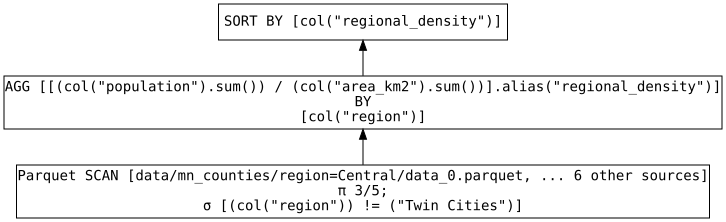

In [637]:
lf.show_graph()

In this case, it made three optimizations relative to the way the code is written:

1. It pushed the filter to the very beginning, to avoid wasting computing grouping and aggregating Twin Cities rows that were just going to be thrown out. Because the data are partitioned by region, it didn't even bother reading the Twin Cities file.
2. It only read 3 of the 5 columns from the file, to avoid wasting compute processing the unused `name` and `fips` columns that were just going to be thrown out.
3. It used a more efficient sorting algorithm that doesn't track anything other than the top 3 results, to avoid wasting compute sorting rows that would just be thrown out when returning `head(3)`.

### Exercise: Analyze data with Polars

- Option 1: On the Python data problems page, do problems 3, 4, and 5. Then answer these questions:
    - Which problems used dataframes? Which used lazyframes? How do you know?
    - In problem 3, why is it smarter to use the `filter` context than the `group_by` context to get the Twin Cities' population?
    - In problem 5, what happens if you move the call to the `tail` method earlier? Why?
    
- Option 2: Use Polars and the data in the `data` directory to answer any (or all) of these questions:
    - What is the total area of Minnesota's Central region in square kilometers?
    - What is the smallest Minnesota region by area?
    - What is the population density of Minnesota?



## DuckDB

A third way data representations may cause problems is by failing to interface well with the source data on disk. That's especially true if either: 
- The data is not on your local machine, but is accessed through a network share or a cloud service
- The data is larger than memory, requiring out-of-core processing

DuckDB is an analytical database engine designed to turn nearly any kind of tabular data into a queryable format, without having to load it into an RDBMS like PostgreSQL or SQL Server. This gives you the full power of SQL even if your data is in some other format.

### The Relational API

The Relational API is the main way to interact with DuckDB in Python. The Relational API relies on two objects:

- `DuckDBPyConnection` (connection): The connection to the database created by `duckdb.connect`. When called without any arguments, the connection is to the default in-memory database that DuckDB creates. It's also possible to specify a DuckDB Database file on disk to connect to.

- `DuckDBPyRelation` (relation): Conceptually identical to a Polars lazyframe. It is a query plan that returns results only when it is materialized. You can materialize a `DuckDBPyRelation` object in a variety of ways, such as passing it to the `print` function, calling the `show` method, or exporting it to some other format.

In [305]:
import duckdb

with duckdb.connect() as con:
    rel = con.sql("""
        SELECT name, area_km2, population
        FROM 'data/mn_counties.parquet'
        WHERE region = 'Central'
    """)

    rel.show()

┌────────────┬──────────┬────────────┐
│    name    │ area_km2 │ population │
│  varchar   │  int64   │   int64    │
├────────────┼──────────┼────────────┤
│ Benton     │     1057 │      41744 │
│ Cass       │     5226 │      31430 │
│ Chisago    │     1082 │      59142 │
│ Crow Wing  │     2581 │      69132 │
│ Isanti     │     1137 │      44386 │
│ Kanabec    │     1360 │      16628 │
│ Mille Lacs │     1488 │      27753 │
│ Morrison   │     2912 │      34620 │
│ Pine       │     3655 │      30472 │
│ Sherburne  │     1130 │     104194 │
│ Stearns    │     3482 │     164110 │
│ Todd       │     2440 │      26060 │
│ Wadena     │     1386 │      14388 │
│ Wright     │     1711 │     157559 │
└────────────┴──────────┴────────────┘
  14 rows                  3 columns



Like Polars, DuckDB can use globbing and directories to read multiple files into a single table, such as hive partitioned parquet files.

In [306]:
import duckdb

with duckdb.connect() as con:
    rel = con.sql("""
        SELECT name, area_km2, population
        FROM 'data/mn_counties/**/*.parquet'
        WHERE region = 'Central'
    """)

    rel.show()

┌────────────┬──────────┬────────────┐
│    name    │ area_km2 │ population │
│  varchar   │  int64   │   int64    │
├────────────┼──────────┼────────────┤
│ Benton     │     1057 │      41744 │
│ Cass       │     5226 │      31430 │
│ Chisago    │     1082 │      59142 │
│ Crow Wing  │     2581 │      69132 │
│ Isanti     │     1137 │      44386 │
│ Kanabec    │     1360 │      16628 │
│ Mille Lacs │     1488 │      27753 │
│ Morrison   │     2912 │      34620 │
│ Pine       │     3655 │      30472 │
│ Sherburne  │     1130 │     104194 │
│ Stearns    │     3482 │     164110 │
│ Todd       │     2440 │      26060 │
│ Wadena     │     1386 │      14388 │
│ Wright     │     1711 │     157559 │
└────────────┴──────────┴────────────┘
  14 rows                  3 columns



DuckDB alternatively supports method-chaining for people who are more comfortable with Python than with SQL

In [310]:
with duckdb.connect() as con:
    rel = (
        con.read_parquet("data/mn_counties/", hive_partitioning=True)
        .filter("region = 'Central'")
        .select("name", "area_km2", "population")
    )
    
    rel.show()

┌────────────┬──────────┬────────────┐
│    name    │ area_km2 │ population │
│  varchar   │  int64   │   int64    │
├────────────┼──────────┼────────────┤
│ Benton     │     1057 │      41744 │
│ Cass       │     5226 │      31430 │
│ Chisago    │     1082 │      59142 │
│ Crow Wing  │     2581 │      69132 │
│ Isanti     │     1137 │      44386 │
│ Kanabec    │     1360 │      16628 │
│ Mille Lacs │     1488 │      27753 │
│ Morrison   │     2912 │      34620 │
│ Pine       │     3655 │      30472 │
│ Sherburne  │     1130 │     104194 │
│ Stearns    │     3482 │     164110 │
│ Todd       │     2440 │      26060 │
│ Wadena     │     1386 │      14388 │
│ Wright     │     1711 │     157559 │
└────────────┴──────────┴────────────┘
  14 rows                  3 columns



### The DB API

The DB API involves working directly with the `DuckDBPyConnection` object instead of creating a relation. The DB API involves using the `execute` method to run SQL queries against the database, then fetching those results into some other data structure, such as a Polars dataframe.

In [609]:
with duckdb.connect() as con:
    con.execute("""
        SELECT name, area_km2, population
        FROM 'data/mn_counties/**/*.parquet'
        WHERE region = 'Central'
    """)
    df = con.pl()

print(df)

shape: (14, 3)
┌───────────┬──────────┬────────────┐
│ name      ┆ area_km2 ┆ population │
│ ---       ┆ ---      ┆ ---        │
│ str       ┆ i64      ┆ i64        │
╞═══════════╪══════════╪════════════╡
│ Benton    ┆ 1057     ┆ 41744      │
│ Cass      ┆ 5226     ┆ 31430      │
│ Chisago   ┆ 1082     ┆ 59142      │
│ Crow Wing ┆ 2581     ┆ 69132      │
│ Isanti    ┆ 1137     ┆ 44386      │
│ …         ┆ …        ┆ …          │
│ Sherburne ┆ 1130     ┆ 104194     │
│ Stearns   ┆ 3482     ┆ 164110     │
│ Todd      ┆ 2440     ┆ 26060      │
│ Wadena    ┆ 1386     ┆ 14388      │
│ Wright    ┆ 1711     ┆ 157559     │
└───────────┴──────────┴────────────┘


A big disadvantage of the DB API is that the `execute` method is eager, not lazy. It materializes the results into memory right away, even if you have additional analysis you want to do that would benefit from additional query optimization. Generally with the `execute` method, you want to put all of your selection logic into a single SQL statement.

### Preventing SQL injection

SQL injection is a type of security exploit that involves getting external malicious SQL code into your SQL statement. To avoid SQL attacks, never use f-strings or string formatting to dynamically build SQL expressions.

For example, if `region` is a user-supplied value that is supposed to limit the query to a single region, a malicious attacker can use SQL injection to get all the values.

In [324]:
region = "Central' OR 1=1;--"

with duckdb.connect() as con:
    rel = con.sql(f"""
        SELECT name, area_km2, population
        FROM 'data/mn_counties/**/*.parquet'
        WHERE region = '{region}'
    """)
    
    rel.show()

┌────────────┬──────────┬────────────┐
│    name    │ area_km2 │ population │
│  varchar   │  int64   │   int64    │
├────────────┼──────────┼────────────┤
│ Benton     │     1057 │      41744 │
│ Cass       │     5226 │      31430 │
│ Chisago    │     1082 │      59142 │
│ Crow Wing  │     2581 │      69132 │
│ Isanti     │     1137 │      44386 │
│ Kanabec    │     1360 │      16628 │
│ Mille Lacs │     1488 │      27753 │
│ Morrison   │     2912 │      34620 │
│ Pine       │     3655 │      30472 │
│ Sherburne  │     1130 │     104194 │
│     ·      │       ·  │        ·   │
│     ·      │       ·  │        ·   │
│     ·      │       ·  │        ·   │
│ Washington │     1014 │     286895 │
│ Becker     │     3394 │      35497 │
│ Clay       │     2707 │      67734 │
│ Douglas    │     1643 │      40120 │
│ Grant      │     1415 │       6085 │
│ Otter Tail │     5127 │      61041 │
│ Pope       │     1736 │      11420 │
│ Stevens    │     1456 │       9747 │
│ Traverse   │     1487 │

The DB API offers a way around this, by using [prepared statements](https://duckdb.org/docs/lts/clients/python/dbapi#prepared-statements) to parameterize queries. There are other options for preventing SQL injection with DuckDB, but prepared statements are the easiest to use effectively.

In [575]:
region = "Central' OR 1=1;--"

with duckdb.connect() as con:
    query = """
        SELECT name, area_km2, population
        FROM 'data/mn_counties/**/*.parquet'
        WHERE region = $select_region
    """

    params = {"select_region": region}

    con.execute(query, parameters=params)
    
    df = con.pl()

df

name,area_km2,population
str,i64,i64


### DuckDB vs. Polars

DuckDB has two major advantages over Polars. The first is that DuckDB is better at handling data that's bigger than memory. DuckDB always spills this kind of data to disk, so you don't get an error saying you ran out of memory. Polars is getting better at this, but large datasets can cause Polars to crash if you're not careful.

The second advantage is that DuckDB can handle spatial data than Polars. DuckDB has a built-in geometry datatype that lets it read spatial data from formats like GeoParquet. And it has a spatial extension that provides functions for manipulating geometry. This lets you do things like select based on a spatial predicate instead of only attributes.

In [ ]:
with duckdb.connect() as con:
    con.execute("INSTALL spatial; LOAD spatial;")

    rel = con.sql("""
        SELECT name_of_program, Shape
        FROM 'data/child_care.gpkg'
        WHERE ST_Distance(Shape, ST_POINT(570000,5183000)) < 1000
    """)

    rel.show()

┌──────────────────────────────┬──────────────────────────────────────────────┐
│       name_of_program        │                    Shape                     │
│           varchar            │            geometry('epsg:26915')            │
├──────────────────────────────┼──────────────────────────────────────────────┤
│ Chester Creek Montessori     │ POINT (570205.5345000001 5183741.5305)       │
│ St. Mary's Child Care Center │ POINT (569233.1084000003 5182615.5923999995) │
│ University Nursery School    │ POINT (569485.2840999998 5183100.7031)       │
└──────────────────────────────┴──────────────────────────────────────────────┘



The advantage of Polars over DuckDB is the way that Polars expressions can be built up dynamically and composed together more easily than SQL statements.

Fortunately, these advantages don't end up trading off, because DuckDB and Polars work well together. DuckDB makes use of the same Apache Arrow memory model that Polars does, which makes passing data between the two very efficient. A good general pattern is to use DuckDB to pull in large datasets (using its superior out-of-core data processing), then use Polars for more sophisticated manipulation (using its superior dynamic expressions).

### Exercise: Query data with DuckDB

- Option 1: On the Python data problems page, do problems 6 and 7. Then answer these questions:
    - Why was hive partitioning useful in problem 6 but not 7?
    - In problem 6, why does the order of `filter` and `select` matter?
    - To what degree does DuckDB's relational API in problem 6 resemble Polar's syntax?
- Option 2: Use DuckDB and the data in the `data` directory to answer any (or all) of these questions:
    - How many counties are in the Northland region?
    - How many counties with under 50,000 people are in each region?
    - How many child care centers are inside the polygon with this WKT representation: 
    
        `'POLYGON((500000 5000000, 501000 5000000, 501000 5001000, 500000 5000000, 500000 5000000))'`
        
        Hint: You will want to look at the the [`ST_Within`](https://duckdb.org/docs/lts/core_extensions/spatial/functions#st_within) and [`ST_GeomFromText`](https://duckdb.org/docs/lts/core_extensions/spatial/functions#st_geomfromtext) functions in the DuckDB spatial extension.

## Putting it all together

In [ ]:
from geojson_pydantic import Polygon
from shapely import shape

geojson = """{
    "type": "Polygon",
    "coordinates": [[[-95, 45], [-94, 45], [-94, 46], [-95, 46], [-95, 45]]]
}"""

user_polygon = Polygon.model_validate_json(geojson)
geom = shape(user_polygon.model_dump())


In [699]:
query = """
    SELECT
        names.primary AS name,
        basic_category,
        ST_AsWKB(geometry)
    FROM 's3://overturemaps-us-west-2/release/2026-08-19.0/theme=places/type=place/*.parquet'
    WHERE bbox.xmin BETWEEN $xmin AND $xmax
      AND bbox.ymin BETWEEN $ymin AND $ymax
      AND ST_Within(geometry, ST_GeomFromWKB($user_polygon_wkb))
"""

params = {
    "user_polygon_wkb": geom.wkb
}
params['xmin'], params['ymin'], params['xmax'], params['ymax'] = geom.bounds


with duckdb.connect() as con:
    con.execute("INSTALL spatial; LOAD spatial;")
    con.execute("INSTALL httpfs; LOAD httpfs;")
    con.execute(query, parameters=params)
    df = con.pl()

df

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

name,basic_category,st_aswkb(geometry)
str,str,binary
"""Kandi-Lake Excavating & Septic""","""home_service""","b""\x01\x01\x00\x00\x00\xfa\xa6\x9f&i\xbdW\xc0\x1f\xbf\x12\xa3B\x80F@"""
"""R Excavating & Septics""","""building_or_construction_servi…","b""\x01\x01\x00\x00\x00\xcb\x9d\xa0\xd8\x8b\xbeW\xc0\x02\x94\xa2\xcc\xfb\x8cF@"""
"""Curves""","""gym""","b""\x01\x01\x00\x00\x00~\xe5Az\x8a\xbfW\xc0\xe8\xc0r\x84\x0c\x8eF@"""
"""Threedom""","""automotive_service""","b""\x01\x01\x00\x00\x00\x91\x0d\xa4\x8bM\xbfW\xc0R\xd6o&\xa6\x8dF@"""
"""Hill's Construction""","""hardware_home_and_garden_store""","b""\x01\x01\x00\x00\x00X\xaas\xc0\x10\xbfW\xc0\xd6\xd1\xe9\\x9c\x8eF@"""
…,…,…
"""Dewey's Guns & Ammo""","""sport_or_fitness_facility""","b""\x01\x01\x00\x00\x00\xa5\x11fQ{\x80W\xc0n\xfa\xcf\xf5\x80\xd9F@"""
"""Up Front Horses""","""sport_or_fitness_facility""","b""\x01\x01\x00\x00\x00\x02\x87iB\x87\x80W\xc0jkD0\x8e\xe4F@"""
"""Twin Pines Tree Care & Landsca…","""hardware_home_and_garden_store""","b""\x01\x01\x00\x00\x00\x08-\xb5M&\x80W\xc0J\xee\x067\x15\xf0F@"""


In [697]:
count_by_category = pl.col("basic_category").len().alias("count")

lf = (
    df.lazy()
    .group_by(pl.col("basic_category"))
    .agg(count_by_category)
    .drop_nulls()
    .sort("count", descending=True)
    .head(5)
)

lf.collect()

basic_category,count
str,u32
"""home_service""",886
"""automotive_service""",555
"""restaurant""",530
"""financial_service""",482
"""personal_or_beauty_service""",459
